In [1]:
import cv2 as cv
import matplotlib.pyplot as plt

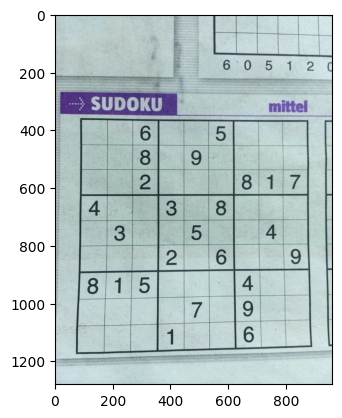

In [2]:
image = cv.imread("/Volumes/T7Storage/image1004.jpg")
plt.imshow(image,cmap="gray")

In [3]:
image = cv.cvtColor(image,cv.COLOR_BGR2GRAY)

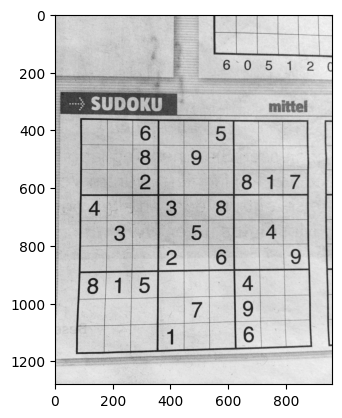

In [4]:
plt.imshow(image,cmap="gray")

In [5]:
blur = cv.bilateralFilter(image,15,100,100)

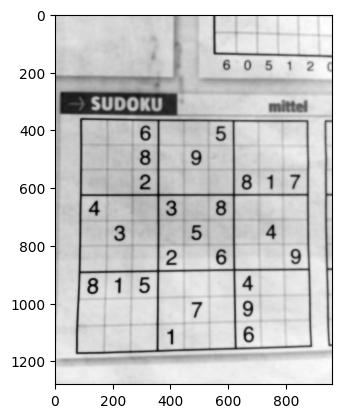

In [6]:
plt.imshow(blur,cmap="gray")

In [7]:
th3 = cv.adaptiveThreshold(blur,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)

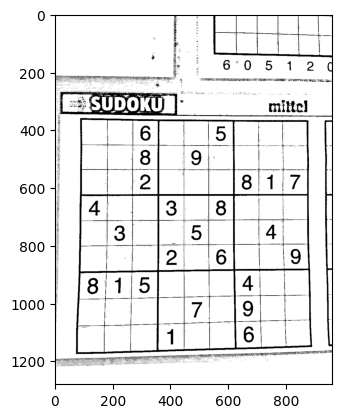

In [8]:
plt.imshow(th3,cmap="gray")

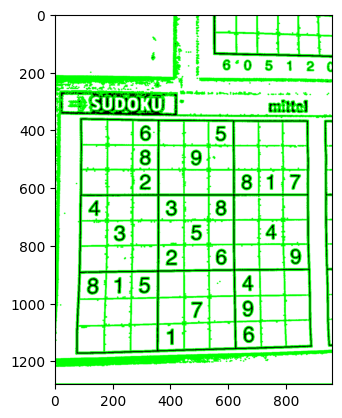

In [9]:
all_contours = th3.copy()
bit_contours = th3.copy()
contours,hierarchy = cv.findContours(th3, mode = cv.RETR_TREE,method = cv.CHAIN_APPROX_SIMPLE)
img_contours1 = cv.cvtColor(th3.copy(), cv.COLOR_GRAY2BGR)
cv.drawContours(image = img_contours1,contours = contours,contourIdx =-1,color=(0,255,0),thickness =2,lineType = cv.LINE_AA)
plt.imshow(img_contours1,cmap="hsv")

In [10]:
#finding the biggest contour
import numpy as np
def biggestContour(contours):
    biggest = np.array([])
    max_area =0
    for i in contours:
        area = cv.contourArea(i)
        if area>50:
            peri = cv.arcLength(i,True)
            approx = cv.approxPolyDP(i,0.02*peri,True)
            if area >max_area and len(approx)==4:
                biggest = approx
                max_area = area

    return biggest,max_area

In [11]:
big,ma =biggestContour(contours)

In [12]:
print(big,ma)
img_contours2 = cv.cvtColor(th3.copy(), cv.COLOR_GRAY2BGR)



[[[  86  361]]

 [[ 873  366]]

 [[ 888 1151]]

 [[  73 1177]]] 638630.5


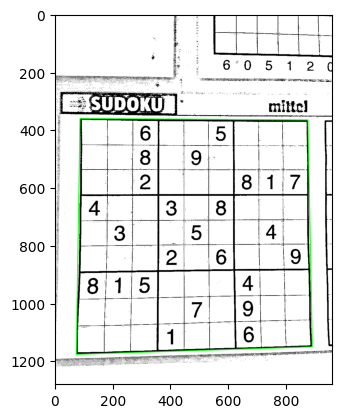

In [13]:
cv.drawContours(image = img_contours2,contours=[big],contourIdx =-1,color=(0,255,0),thickness =2,lineType = cv.LINE_AA)
plt.imshow(img_contours2,cmap="hsv")

In [14]:
def reorder(points):
    points = points.reshape((4,2))
    newpoints=np.zeros((4,2),dtype=np.float32)
    add = points.sum(1)
    newpoints[0] = points[np.argmin(add)]    
    newpoints[3] = points[np.argmax(add)]
    diff = np.diff(points,axis=1)
    newpoints[1] = points[np.argmin(diff)]
    newpoints[2] = points[np.argmax(diff)]
    return newpoints
    

In [15]:
big

array([[[  86,  361]],

       [[ 873,  366]],

       [[ 888, 1151]],

       [[  73, 1177]]], dtype=int32)

In [16]:
pts1 = reorder(big)
pts1

array([[  86.,  361.],
       [ 873.,  366.],
       [  73., 1177.],
       [ 888., 1151.]], dtype=float32)

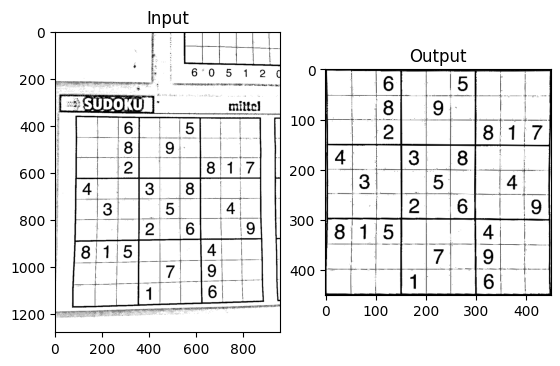

In [27]:

img_contours2 = cv.cvtColor(th3.copy(), cv.COLOR_GRAY2BGR)
pts2 = np.float32([[0,0],[450,0],[0,450],[450,450]])

M = cv.getPerspectiveTransform(pts1,pts2)

dst = cv.warpPerspective(img_contours2,M,(450,450))

plt.subplot(121),plt.imshow(img_contours2,cmap='hsv'),plt.title('Input')
plt.subplot(122),plt.imshow(dst,cmap='hsv'),plt.title('Output')
plt.show()

In [232]:
kernel = np.ones((1,1),np.uint8)
def splitBoxes(img):
    rows = np.vsplit(img,9)
    boxes = []
    for r in rows:
        cols= np.hsplit(r,9)
        for box in cols:
            h,w = box.shape[:2]
            box = box[int(h*0.10):int(h*0.95), int(w*0.15):int(w*0.85)]
            box = cv.cvtColor(box, cv.COLOR_BGR2GRAY)

            box = cv.resize(box, (64,64), interpolation=cv.INTER_AREA)
            # box = cv.equalizeHist(box)
            box = cv.dilate(box,kernel,iterations = 1)

            box = box.astype('float32') / 255.0


            boxes.append(box)
    return boxes

In [233]:
imgsolvedigts = dst.copy()
img = cv.cvtColor(imgsolvedigts, cv.COLOR_BGR2GRAY)
boxes = splitBoxes(imgsolvedigts)

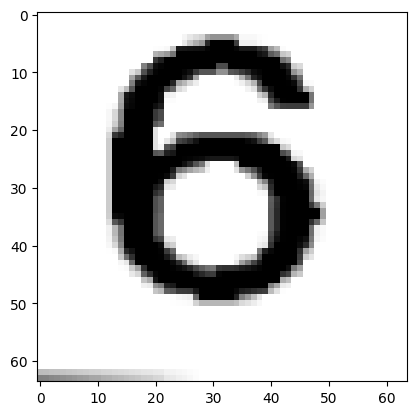

In [234]:
plt.imshow(boxes[50],cmap="gray",vmin=0,vmax=1)


In [235]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class DigitCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # 🔹 Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        x = self.dropout1(x)
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        
        x = self.fc2(x)
        
        return x

In [236]:
model = DigitCNN(10)

model.load_state_dict(
    torch.load("digit_modl.pth")
)

model.eval()

DigitCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [237]:
white_pixels = np.sum(boxes[0])
white_pixels

np.float32(4096.0)

In [238]:
result =[]
model.eval()

for image in boxes:
    total_pixels = image.size
    white_pixels = np.sum(image)  

    ratio = white_pixels / total_pixels

    if ratio > 0.95:
        result.append(0)
    else:
        with torch.no_grad():

            image = torch.tensor(image).unsqueeze(0).unsqueeze(0) 
            output = model(image)
            result.append(torch.argmax(output, dim=1).item())

In [239]:
import numpy as np

grid = np.array(result).reshape(9, 9)

print(grid)

[[0 0 6 0 0 5 0 0 0]
 [0 0 8 0 9 0 0 0 0]
 [0 0 2 0 0 0 8 1 7]
 [4 0 0 3 0 8 0 0 0]
 [0 3 0 0 5 0 0 4 0]
 [0 0 0 2 0 6 0 0 9]
 [8 1 5 0 0 0 4 0 0]
 [0 0 0 0 7 0 9 0 0]
 [0 0 0 1 0 0 6 0 0]]


(<matplotlib.image.AxesImage at 0x304333b20>, Text(0.5, 1.0, 'Output'))

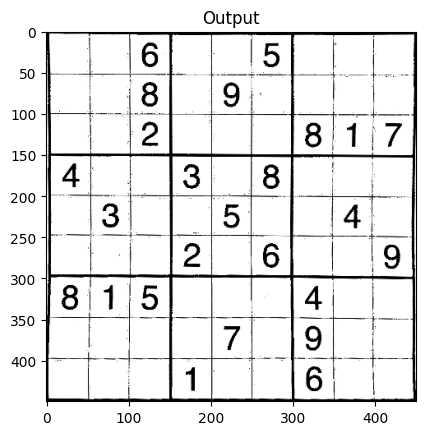

In [227]:
plt.imshow(dst,cmap='hsv'),plt.title('Output')


In [240]:
def find_empty(board):
    for i in range(9):
        for j in range(9):
            if board[i][j] == 0:
                return i, j
    return None


def is_valid(board, num, pos):
    row, col = pos

    for j in range(9):
        if board[row][j] == num and j != col:
            return False

    for i in range(9):
        if board[i][col] == num and i != row:
            return False

    box_x = col // 3
    box_y = row // 3

    for i in range(box_y * 3, box_y * 3 + 3):
        for j in range(box_x * 3, box_x * 3 + 3):
            if board[i][j] == num and (i, j) != pos:
                return False

    return True


def solve(board):
    empty = find_empty(board)
    if not empty:
        return True  

    row, col = empty

    for num in range(1, 10):
        if is_valid(board, num, (row, col)):
            board[row][col] = num

            if solve(board):
                return True

            board[row][col] = 0  

    return False

In [241]:
import numpy as np

grid = np.array(grid).reshape(9, 9).tolist()

if solve(grid):
    print("Solved Sudoku:\n")
    for row in grid:
        print(row)
else:
    print("No solution found")

Solved Sudoku:

[1, 7, 6, 8, 2, 5, 3, 9, 4]
[3, 4, 8, 7, 9, 1, 5, 2, 6]
[9, 5, 2, 4, 6, 3, 8, 1, 7]
[4, 2, 9, 3, 1, 8, 7, 6, 5]
[6, 3, 1, 9, 5, 7, 2, 4, 8]
[5, 8, 7, 2, 4, 6, 1, 3, 9]
[8, 1, 5, 6, 3, 9, 4, 7, 2]
[2, 6, 3, 5, 7, 4, 9, 8, 1]
[7, 9, 4, 1, 8, 2, 6, 5, 3]
